# 04 - CMOS / CCD Camera Noise, Dynamic Range, and MTF Simulator

This notebook models the camera signal chain in electrons, then visualizes how
exposure, full well, ADC depth, hot pixels, flat-field error, and PSF blur affect
image quality.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src import plotting

plotting.set_style()
FIG_DIR = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

from scipy.ndimage import gaussian_filter
from src.detector import CameraParams, camera_noise_budget, simulate_camera_frame, gaussian_mtf

## 1. Engineering Problem

Choose exposure and sensor settings that produce useful SNR without saturation
or image-quality loss. This is relevant to machine vision, microscopy, astronomy
instrumentation, semiconductor imaging, and camera characterization.

## 2. Physical Assumptions

- Photon and dark-current arrival are Poisson processes.
- Read noise is Gaussian in electron units.
- Quantization noise is uniform over one ADC code.
- Full-well capacity clips charge before digitization.
- PRNU is modeled as multiplicative pixel-response variation.
- Hot pixels have much larger dark current.
- Optical blur is represented by a Gaussian PSF and its MTF.

## 3. System Parameters

In [2]:
params = CameraParams(
    quantum_efficiency=0.62,
    dark_current_e_per_s=0.8,
    read_noise_e=2.2,
    full_well_e=30_000.0,
    bit_depth=12,
    prnu_fraction=0.01,
    hot_pixel_fraction=0.001,
    hot_pixel_dark_current_e_per_s=100.0,
)

pd.DataFrame(
    [
        ("quantum_efficiency", params.quantum_efficiency, "fraction", "Photon-to-electron conversion efficiency."),
        ("dark_current_e_per_s", params.dark_current_e_per_s, "e/s/pixel", "Thermal generation rate per pixel."),
        ("read_noise_e", params.read_noise_e, "e RMS", "Electronics noise after charge collection."),
        ("full_well_e", params.full_well_e, "e", "Maximum charge before saturation/clipping."),
        ("bit_depth", params.bit_depth, "bits", "ADC quantization depth."),
        ("prnu_fraction", params.prnu_fraction, "fraction RMS", "Pixel-response non-uniformity."),
        ("hot_pixel_fraction", params.hot_pixel_fraction, "fraction", "Fraction of pixels with high dark current."),
    ],
    columns=["parameter", "value", "unit", "engineering meaning"],
)

,parameter,value,unit,engineering meaning
0,quantum_efficiency,0.620,fraction,Photon-to-electron conversion efficiency.
1,dark_current_e_per_s,0.800,e/s/pixel,Thermal generation rate per pixel.
2,read_noise_e,2.200,e RMS,Electronics noise after charge collection.
3,full_well_e,30000.000,e,Maximum charge before saturation/clipping.
4,bit_depth,12.000,bits,ADC quantization depth.
5,prnu_fraction,0.010,fraction RMS,Pixel-response non-uniformity.
6,hot_pixel_fraction,0.001,fraction,Fraction of pixels with high dark current.


## 4. Simulation Model

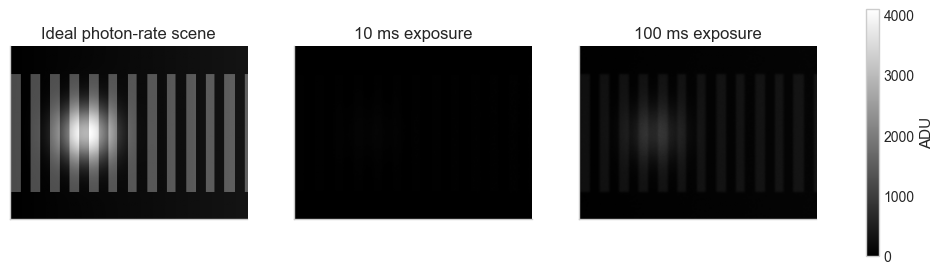

In [3]:
ny, nx = 160, 220
y, x = np.mgrid[0:ny, 0:nx]
scene_rate = 2_000 + 70_000 * np.exp(-((x - 70) ** 2 + (y - 80) ** 2) / (2 * 18**2))
scene_rate += 30_000 * (np.sin(2 * np.pi * x / 18) > 0) * (y > 25) * (y < 135)
scene_rate += 8_000 * (x / nx)
blurred_rate = gaussian_filter(scene_rate, sigma=1.0)

frame_short = simulate_camera_frame(blurred_rate, 0.01, params, seed=2)
frame_long = simulate_camera_frame(blurred_rate, 0.10, params, seed=2)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
im0 = axes[0].imshow(scene_rate, cmap="gray")
axes[0].set_title("Ideal photon-rate scene")
im1 = axes[1].imshow(frame_short["adu"], cmap="gray", vmin=0, vmax=2**params.bit_depth - 1)
axes[1].set_title("10 ms exposure")
im2 = axes[2].imshow(frame_long["adu"], cmap="gray", vmin=0, vmax=2**params.bit_depth - 1)
axes[2].set_title("100 ms exposure")
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
fig.colorbar(im2, ax=axes, shrink=0.8, label="ADU")
plt.show()

## 5. Noise / Uncertainty Model

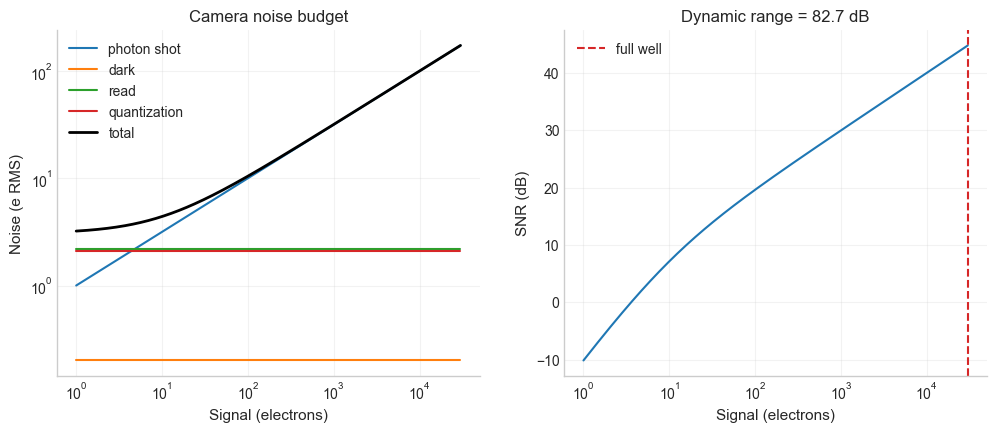

In [4]:
signal_e = np.logspace(0, np.log10(params.full_well_e), 300)
budget = camera_noise_budget(signal_e, exposure_s=0.05, params=params)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].loglog(signal_e, budget["shot_noise_e"], label="photon shot")
axes[0].loglog(signal_e, budget["dark_noise_e"], label="dark")
axes[0].loglog(signal_e, budget["read_noise_e"], label="read")
axes[0].loglog(signal_e, budget["quantization_noise_e"], label="quantization")
axes[0].loglog(signal_e, budget["total_noise_e"], "k", lw=2, label="total")
axes[0].set_xlabel("Signal (electrons)")
axes[0].set_ylabel("Noise (e RMS)")
axes[0].set_title("Camera noise budget")
axes[0].legend()

axes[1].semilogx(signal_e, budget["snr_db"])
axes[1].axvline(params.full_well_e, color="tab:red", ls="--", label="full well")
axes[1].set_xlabel("Signal (electrons)")
axes[1].set_ylabel("SNR (dB)")
axes[1].set_title(f"Dynamic range = {budget['dynamic_range_db']:.1f} dB")
axes[1].legend()
plt.show()

## 6. Parameter Scan

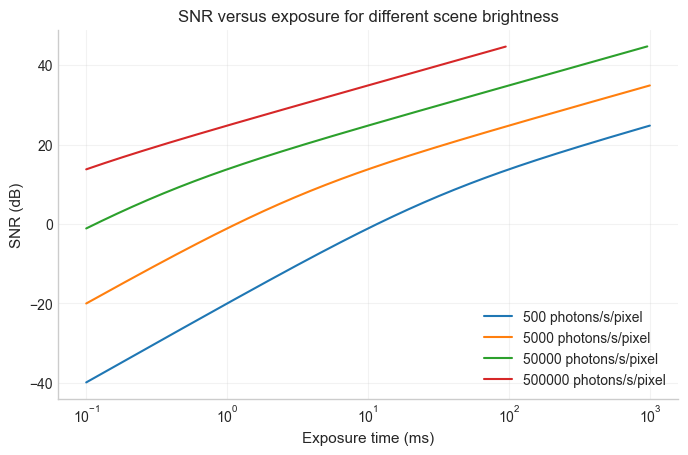

In [5]:
exposures_s = np.logspace(-4, 0, 220)
photon_rates = [500, 5_000, 50_000, 500_000]

fig, ax = plt.subplots()
for rate in photon_rates:
    signal = params.quantum_efficiency * rate * exposures_s
    snr_db = camera_noise_budget(signal, exposures_s[0], params)["snr_db"]
    saturated = signal >= params.full_well_e
    snr_db = np.where(saturated, np.nan, snr_db)
    ax.semilogx(exposures_s * 1e3, snr_db, label=f"{rate:g} photons/s/pixel")
ax.set_xlabel("Exposure time (ms)")
ax.set_ylabel("SNR (dB)")
ax.set_title("SNR versus exposure for different scene brightness")
ax.legend()
plt.show()

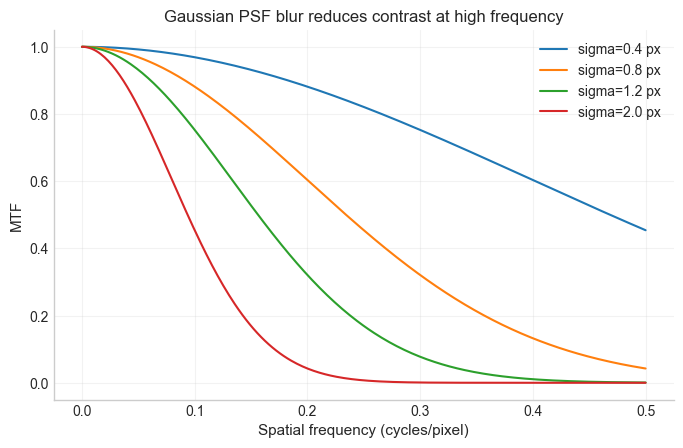

In [6]:
freq = np.linspace(0, 0.5, 300)
sigma_values = [0.4, 0.8, 1.2, 2.0]

fig, ax = plt.subplots()
for sigma in sigma_values:
    ax.plot(freq, gaussian_mtf(freq, sigma), label=f"sigma={sigma} px")
ax.set_xlabel("Spatial frequency (cycles/pixel)")
ax.set_ylabel("MTF")
ax.set_title("Gaussian PSF blur reduces contrast at high frequency")
ax.legend()
plt.show()

## 7. Failure Regime

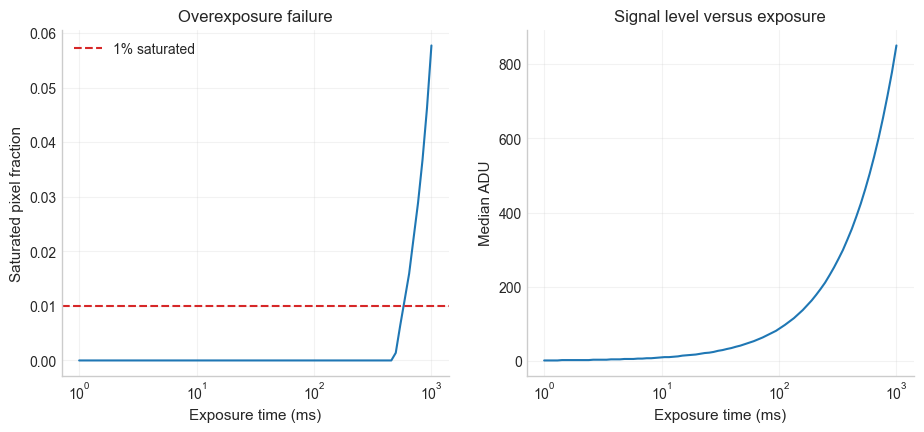

In [7]:
exposure_scan = np.logspace(-3, 0, 80)
saturation_fraction = []
hot_counts = []
median_adu = []

for exposure in exposure_scan:
    frame = simulate_camera_frame(blurred_rate, exposure, params, seed=3)
    saturation_fraction.append(np.mean(frame["electrons"] >= params.full_well_e))
    hot_counts.append(np.sum(frame["hot_pixel_mask"]))
    median_adu.append(np.median(frame["adu"]))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].semilogx(exposure_scan * 1e3, saturation_fraction)
axes[0].axhline(0.01, color="tab:red", ls="--", label="1% saturated")
axes[0].set_xlabel("Exposure time (ms)")
axes[0].set_ylabel("Saturated pixel fraction")
axes[0].set_title("Overexposure failure")
axes[0].legend()

axes[1].semilogx(exposure_scan * 1e3, median_adu)
axes[1].set_xlabel("Exposure time (ms)")
axes[1].set_ylabel("Median ADU")
axes[1].set_title("Signal level versus exposure")
plt.show()

## 8. Design Trade-Off

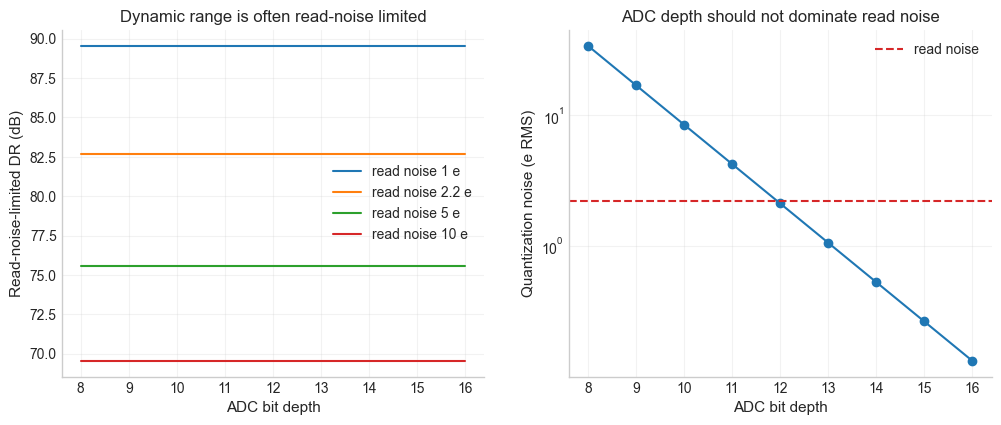

In [8]:
bit_depths = np.arange(8, 17)
read_noises = np.array([1.0, 2.2, 5.0, 10.0])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for rn in read_noises:
    dr = 20 * np.log10(params.full_well_e / rn)
    axes[0].plot(bit_depths, [dr] * len(bit_depths), label=f"read noise {rn:g} e")
axes[0].set_xlabel("ADC bit depth")
axes[0].set_ylabel("Read-noise-limited DR (dB)")
axes[0].set_title("Dynamic range is often read-noise limited")
axes[0].legend()

full_scale = params.full_well_e
quant_noise = full_scale / (2**bit_depths - 1) / np.sqrt(12)
axes[1].plot(bit_depths, quant_noise, marker="o")
axes[1].axhline(params.read_noise_e, color="tab:red", ls="--", label="read noise")
axes[1].set_yscale("log")
axes[1].set_xlabel("ADC bit depth")
axes[1].set_ylabel("Quantization noise (e RMS)")
axes[1].set_title("ADC depth should not dominate read noise")
axes[1].legend()
plt.show()

## 9. Key Engineering Conclusions

- Camera SNR should be analyzed in electrons first; ADU values hide the physics.
- At low signal, read noise and quantization can dominate; at high signal, photon
  shot noise dominates until full-well saturation.
- Longer exposure improves SNR only until full-well clipping, motion blur, or
  dark current becomes limiting.
- Dynamic range depends strongly on full-well capacity and read noise; increasing
  ADC bit depth helps only if quantization noise is comparable to other noises.
- PRNU and hot pixels are calibration problems, not just random-noise problems.
- MTF connects optics and sensor sampling: a high-SNR image can still fail if PSF
  blur removes the spatial frequencies required by the application.